The objective of this notebook is to understand demand, capacity, and cost drivers within the transportation network.

The findings will be used to prepare optimization-ready datasets and identify potential bottlenecks.

In [2]:
# Import libraries for data analysis and visualization

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Display settings for easier dataframe review
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# Load all tables from the supply chain workbook

file_path = "../data/raw/Supply chain logistics problem.xlsx"

order_list = pd.read_excel(file_path, sheet_name="OrderList")
freight_rates = pd.read_excel(file_path, sheet_name="FreightRates")
wh_costs = pd.read_excel(file_path, sheet_name="WhCosts")
wh_capacities = pd.read_excel(file_path, sheet_name="WhCapacities")
products_per_plant = pd.read_excel(file_path, sheet_name="ProductsPerPlant")
vmi_customers = pd.read_excel(file_path, sheet_name="VmiCustomers")
plant_ports = pd.read_excel(file_path, sheet_name="PlantPorts")

In [4]:
# Calculate total customer demand from historical orders

customer_demand = (
    order_list
    .groupby('Customer')['Unit quantity']
    .sum()
    .sort_values(ascending=False)
)

customer_demand.head(10)

Customer
V55555555_5            8020417
V55555555555_28        5293676
V55555555_32           1914858
V55555_26              1909058
V55555_2               1512452
V555555_6              1220461
V555555555555555_29    1054980
V5555_36                931678
V55555555_7             927068
V55555555555555_8       877824
Name: Unit quantity, dtype: int64

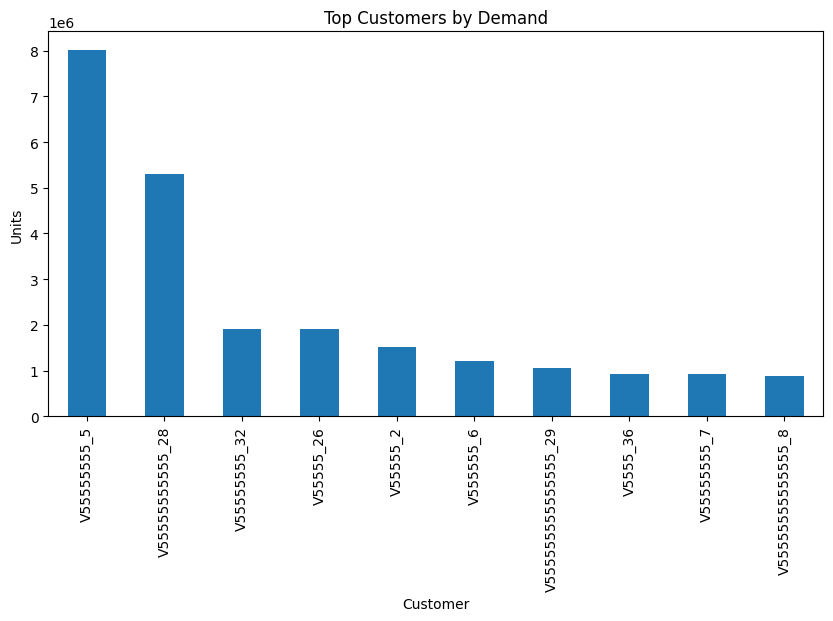

In [5]:
# Visualize largest demand customers

customer_demand.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top Customers by Demand'
)

plt.ylabel('Units')
plt.show()

In [7]:
# Remove leading/trailing spaces from all column names

for df in [order_list, freight_rates, wh_costs, wh_capacities,
           products_per_plant, vmi_customers, plant_ports]:
    df.columns = df.columns.str.strip()

In [8]:
# Review plant capacities

wh_capacities.sort_values(
    by='Daily Capacity',
    ascending=False
)

,Plant ID,Daily Capacity
5,PLANT01,1070
14,PLANT03,1013
18,PLANT04,554
9,PLANT14,549
15,PLANT13,490
10,PLANT16,457
3,PLANT05,385
12,PLANT11,332
8,PLANT07,265
11,PLANT12,209


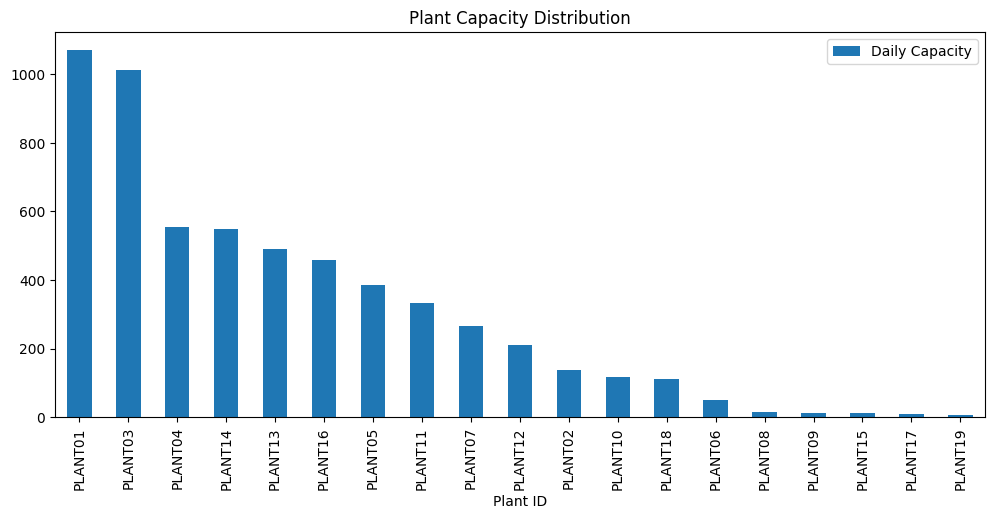

In [9]:
# Visualize capacity distribution

wh_capacities.sort_values(
    by='Daily Capacity',
    ascending=False
).plot(
    x='Plant ID',
    y='Daily Capacity',
    kind='bar',
    figsize=(12,5)
)

plt.title('Plant Capacity Distribution')
plt.show()

In [10]:
# Review warehouse costs

wh_costs.sort_values(
    by='Cost/unit',
    ascending=False
)

,WH,Cost/unit
2,PLANT18,2.036254
10,PLANT16,1.919808
0,PLANT15,1.415063
11,PLANT12,0.773132
16,PLANT19,0.639763
9,PLANT14,0.634330
5,PLANT01,0.566976
12,PLANT11,0.555247
6,PLANT06,0.554088
17,PLANT08,0.522857


In [11]:
total_demand = order_list['Unit quantity'].sum()

total_capacity = wh_capacities['Daily Capacity'].sum()

print("Total Demand:", total_demand)
print("Total Capacity:", total_capacity)

Total Demand: 29513315
Total Capacity: 5791


Initial comparison shows that historical demand greatly exceeds total daily plant capacity.

However, these measures are not directly comparable because:

- Order demand represents cumulative historical shipments.
- Plant capacities represent daily production capacity.

A normalized demand analysis will be required before optimization modeling.

In [12]:
# Review order date range

order_list['Order Date'] = pd.to_datetime(order_list['Order Date'])

print("Min Date:", order_list['Order Date'].min())
print("Max Date:", order_list['Order Date'].max())

print("Unique Days:", order_list['Order Date'].nunique())

Min Date: 2013-05-26 00:00:00
Max Date: 2013-05-26 00:00:00
Unique Days: 1


In [13]:
# Average daily demand

daily_demand = (
    order_list
    .groupby('Order Date')['Unit quantity']
    .sum()
)

print("Average Daily Demand:", round(daily_demand.mean(), 2))
print("Max Daily Demand:", round(daily_demand.max(), 2))

Average Daily Demand: 29513315.0
Max Daily Demand: 29513315


In [14]:
# Inspect capacity table structure

print(wh_capacities.columns.tolist())

wh_capacities.head()

['Plant ID', 'Daily Capacity']


,Plant ID,Daily Capacity
0,PLANT15,11
1,PLANT17,8
2,PLANT18,111
3,PLANT05,385
4,PLANT02,138


In [15]:
# Inspect warehouse costs structure

print(wh_costs.columns.tolist())

wh_costs.head()

['WH', 'Cost/unit']


,WH,Cost/unit
0,PLANT15,1.415063
1,PLANT17,0.428947
2,PLANT18,2.036254
3,PLANT05,0.488144
4,PLANT02,0.477504


In [17]:
customer_demand = (
    order_list
    .groupby('Customer')['Unit quantity']
    .sum()
    .sort_values(ascending=False)
)

customer_demand.head(10)

Customer
V55555555_5            8020417
V55555555555_28        5293676
V55555555_32           1914858
V55555_26              1909058
V55555_2               1512452
V555555_6              1220461
V555555555555555_29    1054980
V5555_36                931678
V55555555_7             927068
V55555555555555_8       877824
Name: Unit quantity, dtype: int64

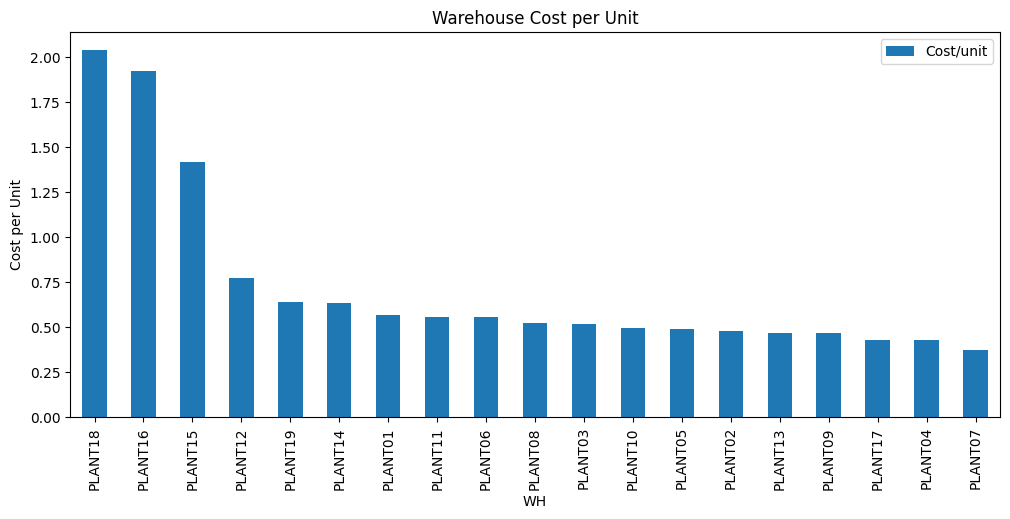

In [19]:
# Visualize warehouse cost distribution

cost_ranking.plot(
    x='WH',
    y='Cost/unit',
    kind='bar',
    figsize=(12,5)
)

plt.title('Warehouse Cost per Unit')
plt.ylabel('Cost per Unit')
plt.show()

### Capacity Concentration

Network capacity is heavily concentrated among a small number of facilities.

PLANT01 and PLANT03 alone account for approximately 36% of total network capacity.

Several facilities have extremely limited capacity and are unlikely to materially influence network throughput.

This suggests that operational disruptions at a small number of high-capacity plants could have a disproportionate impact on network performance.

### Cost Variability

Warehouse operating costs vary substantially across the network.

The most expensive facility (PLANT18) costs over five times more per unit than the least expensive facility (PLANT07).

This creates significant opportunities for cost optimization through intelligent allocation of customer demand across available facilities.

However, low-cost facilities may be constrained by limited capacity, requiring tradeoffs between cost efficiency and network feasibility.

In [20]:
# Review freight rate structure

freight_rates.head()

,Carrier,orig_port_cd,dest_port_cd,minm_wgh_qty,max_wgh_qty,svc_cd,minimum cost,rate,mode_dsc,tpt_day_cnt,Carrier type
0,V444_6,PORT08,PORT09,250.0,499.99,DTD,43.2272,0.7132,AIR,2,V88888888_0
1,V444_6,PORT08,PORT09,65.0,69.99,DTD,43.2272,0.7512,AIR,2,V88888888_0
2,V444_6,PORT08,PORT09,60.0,64.99,DTD,43.2272,0.7892,AIR,2,V88888888_0
3,V444_6,PORT08,PORT09,50.0,54.99,DTD,43.2272,0.8272,AIR,2,V88888888_0
4,V444_6,PORT08,PORT09,35.0,39.99,DTD,43.2272,1.0552,AIR,2,V88888888_0


In [21]:
# Review freight rate statistics

freight_rates.describe(include='all')

,Carrier,orig_port_cd,dest_port_cd,minm_wgh_qty,max_wgh_qty,svc_cd,minimum cost,rate,mode_dsc,tpt_day_cnt,Carrier type
count,1540,1540,1540,1540.000000,1540.000000,1540,1540.000000,1540.000000,1540,1540.000000,1540
unique,9,10,1,NaN,NaN,2,NaN,NaN,2,NaN,2
top,V444_4,PORT06,PORT09,NaN,NaN,DTD,NaN,NaN,AIR,NaN,V888888883_1
freq,906,479,1540,NaN,NaN,1322,NaN,NaN,1511,NaN,1198
mean,NaN,NaN,NaN,155.886637,4636.143633,NaN,12.329033,2.892656,NaN,2.186364,NaN
std,NaN,NaN,NaN,475.952049,20251.309727,NaN,22.946192,4.603877,NaN,2.000895,NaN
min,NaN,NaN,NaN,0.000000,0.453592,NaN,1.202000,0.033200,NaN,0.000000,NaN
25%,NaN,NaN,NaN,15.010000,21.500000,NaN,3.656800,0.470400,NaN,1.000000,NaN
50%,NaN,NaN,NaN,41.010000,47.500000,NaN,7.417000,1.661200,NaN,2.000000,NaN
75%,NaN,NaN,NaN,67.229614,99.990000,NaN,11.494500,3.932200,NaN,2.000000,NaN


In [22]:
# Review freight rate columns

print(freight_rates.columns.tolist())

['Carrier', 'orig_port_cd', 'dest_port_cd', 'minm_wgh_qty', 'max_wgh_qty', 'svc_cd', 'minimum cost', 'rate', 'mode_dsc', 'tpt_day_cnt', 'Carrier type']


### Notebook 2 Summary

The network is heavily dependent on air transportation.

While air transport provides faster transit times, it generally introduces higher transportation costs than ground alternatives.

This dependency may create opportunities for future optimization through mode selection and service-level tradeoffs.
The freight network supports multiple service levels, providing flexibility between transportation cost and delivery performance.

Service-level selection may become an important decision variable in future optimization scenarios.
Transit times range from same-day service to two-week delivery windows.

This variability introduces potential tradeoffs between transportation cost and service performance.

Future optimization models can incorporate service constraints to balance these competing objectives.

In [23]:
# Review carrier usage across freight lanes

freight_rates['Carrier'].value_counts()

Carrier
V444_4    906
V444_1    292
V444_8    100
V444_5     84
V444_2     75
V444_0     39
V444_6     38
V444_9      5
V444_7      1
Name: count, dtype: int64

In [24]:
# Review transportation mode distribution

freight_rates['mode_dsc'].value_counts()

mode_dsc
AIR       1511
GROUND      29
Name: count, dtype: int64

In [25]:
# Review service-level distribution

freight_rates['svc_cd'].value_counts()

svc_cd
DTD    1322
DTP     218
Name: count, dtype: int64

In [26]:
# Review transit-time distribution

freight_rates['tpt_day_cnt'].describe()

count    1540.000000
mean        2.186364
std         2.000895
min         0.000000
25%         1.000000
50%         2.000000
75%         2.000000
max        14.000000
Name: tpt_day_cnt, dtype: float64

In [27]:
# Review freight-rate distribution

freight_rates['rate'].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    1540.000000
mean        2.892656
std         4.603877
min         0.033200
25%         0.470400
50%         1.661200
75%         3.932200
90%         6.553913
95%         9.679323
99%        16.382104
max       128.027200
Name: rate, dtype: float64

The network presents several opportunities for optimization:

- Allocate volume toward lower-cost facilities.
- Reduce reliance on high-cost plants where feasible.
- Evaluate transportation routing decisions.
- Balance cost minimization against capacity constraints and service requirements.